# Qubit States and the Bloch Sphere

### Student Assignment

This assignment covers the six topics from the lecture, qubit states as vectors, the Bloch sphere, state preparation with Ry and Rz, the Born rule, multi qubit tensor states, and the difference between product and entangled states.

Run the import cell first, then write your code in the empty cells provided.

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator

## Question 1, Qubit States as Vectors

Build a single qubit circuit and apply one X gate followed by one H gate.

Extract the statevector and print it.

Then compute and print the norm of the statevector to confirm it is a valid quantum state. On paper, work out which named state this is.

In [ ]:
# Your code here
qc=QuantumCircuit(1);

state = Statevector(qc)
print(state.data)
qc.x(0)

state_x = Statevector(qc)
print(state_x.data)
qc.h(0)
state_h = Statevector(qc)
print(state_h.data)

norm=np.linalg.norm(state_h.data)
print(norm)

# The named state is the minus state ∣−⟩

[1.+0.j 0.+0.j]
[0.+0.j 1.+0.j]
[ 0.70710678+0.j -0.70710678+0.j]
0.9999999999999999


## Question 2, The Bloch Sphere

Prepare the state from Question 1 again and display it on the Bloch sphere using `plot_bloch_multivector`.

In a comment, state where the arrow points and how it differs from the state produced by H alone.

[ 0.70710678+0.j -0.70710678+0.j]


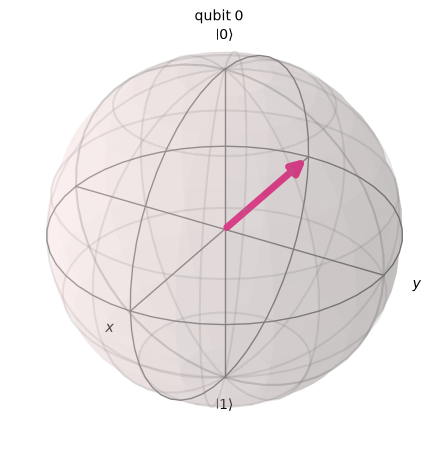

In [ ]:
qc=QuantumCircuit(1);

#state = Statevector(qc)
#print(state.data)
#plot_bloch_multivector(state)
qc.x(0)

#state_x = Statevector(qc)
#print(state_x.data)
#plot_bloch_multivector(state_x)
qc.h(0)
state_h = Statevector(qc)
print(state_h.data)
plot_bloch_multivector(state_h)

#norm=np.linalg.norm(state_h.data)
#print(norm)
#plot_bloch_multivector(state_h) shows the arrow pointing along the negative x-axis.



## Question 3, State Preparation with Ry and Rz

Prepare the state

$$|\psi\rangle = \cos\frac{\pi}{8}|0\rangle + \sin\frac{\pi}{8}|1\rangle$$

using a single Ry rotation. Think carefully about what angle to pass to the gate.

Print the statevector and confirm the two amplitudes match $\cos(\pi/8)$ and $\sin(\pi/8)$ computed directly with NumPy.

Then add an Rz rotation of $\pi$ and show, by printing absolute values, that the measurement probabilities have not changed.

In [12]:
# Your code here
theta = np.pi / 4

# Ry(theta)|0> produces cos(theta/2)|0> + sin(theta/2)|1>
qc = QuantumCircuit(1)
qc.ry(theta, 0)

state_ry = Statevector(qc)

expected = np.array([
    np.cos(np.pi / 8),
    np.sin(np.pi / 8)
], dtype=complex)

print("Statevector after Ry:")
print(state_ry.data)

print("Expected amplitudes:")
print(expected)

print("Amplitudes match:", np.allclose(state_ry.data, expected))

# Add Rz(pi), which changes phases but not computational-basis probabilities
qc.rz(np.pi, 0)
state_ry_rz = Statevector(qc)

print("\nStatevector after Ry followed by Rz(pi):")
print(state_ry_rz.data)

print("Absolute values before Rz:")
print(np.abs(state_ry.data))

print("Absolute values after Rz:")
print(np.abs(state_ry_rz.data))

print(
    "Measurement probabilities unchanged:",
    np.allclose(np.abs(state_ry.data), np.abs(state_ry_rz.data))
)


Statevector after Ry:
[0.92387953+0.j 0.38268343+0.j]
Expected amplitudes:
[0.92387953+0.j 0.38268343+0.j]
Amplitudes match: True

Statevector after Ry followed by Rz(pi):
[5.65713056e-17-0.92387953j 2.34326020e-17+0.38268343j]
Absolute values before Rz:
[0.92387953 0.38268343]
Absolute values after Rz:
[0.92387953 0.38268343]
Measurement probabilities unchanged: True


## Question 4, The Born Rule

Prepare a qubit with `ry(2 * np.pi / 5, 0)` and add a measurement.

First compute the predicted probabilities $P(0)$ and $P(1)$ from the Born rule using NumPy.

Then run the circuit on the AerSimulator with 8192 shots, compute the empirical frequencies from the counts, and print both the predictions and the measured frequencies side by side.

In a comment, explain why the two do not match exactly.

In [13]:
# Your code here
theta = 2 * np.pi / 5
shots = 8192

# Prepare the qubit and add a measurement
qc = QuantumCircuit(1, 1)
qc.ry(theta, 0)
qc.measure(0, 0)

# Born-rule predictions:
# Ry(theta)|0> = cos(theta/2)|0> + sin(theta/2)|1>
p0 = np.cos(theta / 2) ** 2
p1 = np.sin(theta / 2) ** 2

# Run the measured circuit on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=shots).result()
counts = result.get_counts()

# Convert counts into empirical frequencies
frequency_0 = counts.get("0", 0) / shots
frequency_1 = counts.get("1", 0) / shots

print("Outcome    Born-rule probability    Measured frequency")
print(f"0          {p0:.6f}                  {frequency_0:.6f}")
print(f"1          {p1:.6f}                  {frequency_1:.6f}")

# The values do not match exactly because measurements are random samples.
# With a finite number of shots, statistical sampling noise is expected.


Outcome    Born-rule probability    Measured frequency
0          0.654508                  0.651245
1          0.345492                  0.348755


## Question 5, Multi Qubit Tensor States

Build a two qubit circuit where qubit 1 gets an X gate and qubit 0 gets nothing.

Print the four entry statevector from Qiskit.

Then reproduce the same vector by hand using `np.kron` on the appropriate single qubit kets, and print it for comparison. Remember the Qiskit qubit ordering convention from the lecture.

In [14]:
# Your code here
# Build a two-qubit circuit.
# Qubit 1 gets X; qubit 0 remains in |0>.
qc = QuantumCircuit(2)
qc.x(1)

# Statevector from Qiskit
state_qiskit = Statevector(qc)

print("Statevector from Qiskit:")
print(state_qiskit.data)

# Single-qubit basis states
ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

# Qiskit displays basis states as |q1 q0>.
# Therefore, q1 is the first tensor factor and q0 is the second.
state_by_hand = np.kron(ket_1, ket_0)

print("\nStatevector constructed with np.kron:")
print(state_by_hand)

print("\nVectors match:", np.allclose(state_qiskit.data, state_by_hand))

Statevector from Qiskit:
[0.+0.j 0.+0.j 1.+0.j 0.+0.j]

Statevector constructed with np.kron:
[0.+0.j 0.+0.j 1.+0.j 0.+0.j]

Vectors match: True


## Question 6, Product Versus Entangled

Build the circuit that applies H to qubit 0 followed by CNOT with qubit 0 as control and qubit 1 as target, but insert an X gate on qubit 1 before the CNOT.

The resulting state is $\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$, a different Bell state from the lecture.

Apply the determinant test to decide whether this state is a product state or entangled.

Then add measurements, run 4096 shots, and print the counts. In a comment, describe the correlation pattern you observe and how it differs from the Bell state seen in the lecture.

In [15]:
# Your code here
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)

# build the circuit
qc.h(0)
qc.x(1)
qc.cx(0, 1)

state = Statevector(qc)
print("Statevector:", state.data)

a, b, c, d = state.data
determinant = a * d - b * c
print("Determinant test:", determinant)
print(
    "State is entangled"
    if not np.isclose(determinant, 0)
    else "State is a product state"
)

qc.measure([0, 1], [0, 1])

sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=4096).result()
counts = result.get_counts()
print("Counts:", counts)

Statevector: [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
Determinant test: (-0.4999999999999999+0j)
State is entangled
Counts: {'01': 2046, '10': 2050}
